In [67]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ERROR! Session/line number was not unique in database. History logging moved to new session 6992


In [68]:
from tqdm import tqdm
tqdm.pandas()

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

In [2]:
import warnings
warnings.simplefilter("ignore", FutureWarning)

In [3]:
root_path   = os.getcwd()
data_path   = os.path.join(root_path, "data")
signal_path = os.path.join(data_path, "GenericSignal", "GenericSignal.parquet")
fut_path    = os.path.join(data_path, "FuturesData", "PrepFuturesPX.parquet")
trend_path  = os.path.join(data_path, "Benchmarks", "TrendIndices.parquet")
ticker_path = os.path.join(data_path, "TickerGuide.xlsx")

In [6]:
df_wider = (pd.read_parquet(
    path = fut_path, engine = "pyarrow").
    pivot(index = "date", columns = "ticker", values = "px_val"))

In [46]:
windows = [i for i in range(2, 260) if i % 10 == 0]

In [47]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\GenericSignal\FuturesDt.parquet"
df_dt = (pd.read_parquet(
    path = path, engine = "pyarrow").
    pivot(index = "date", columns = "ticker", values = "dt"))

In [48]:
df_signal = pd.DataFrame()

for window in tqdm(windows): 

    df_tmp = (df_dt.apply(
        lambda x: x.ewm(span = window, adjust = False).mean().shift()).
        reset_index().
        melt(id_vars = "date", value_name = "lag_signal").
        dropna().
        assign(window = window))

    df_signal = pd.concat([df_tmp, df_signal])

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [00:07<00:00,  3.39it/s]


In [49]:
path   = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\FuturesData\PrepFuturesPX.parquet"
df_rtn = (pd.read_parquet(
    path = path, engine = "pyarrow").
    pivot(index = "date", columns = "ticker", values = "px_val").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna())

In [50]:
df_signal_combined = (df_signal.merge(
    right = df_rtn, how = "inner", on = ["date", "ticker"]))

In [70]:
def _get_signal_betas(df: pd.DataFrame, window: int) -> pd.DataFrame: 

    df_tmp = (df.reset_index().pivot(
        index = ["date", "rtn"], columns = "window", values = "lag_signal").
        reset_index().
        set_index("date"))

    columns   = df_tmp.columns.to_list()
    exog_cols = list(set(columns) - set(["rtn"]))

    df_out = (RollingOLS(
        endog  = df_tmp["rtn"],
        exog   = sm.add_constant(df_tmp[exog_cols]),
        window = window).
        fit().
        params.
        reset_index().
        melt(id_vars = "date").
        dropna())

    return df_out

window         = 250
df_signal_beta = (df_signal_combined.set_index(
    "date").
    groupby("ticker").
    progress_apply(lambda group: _get_signal_betas(group, window)))

100%|██████████████████████████████████████████████████████████████████████████████████| 88/88 [02:54<00:00,  1.98s/it]


In [78]:
df_signal_beta_tmp = (df_signal_beta.reset_index().query(
    "variable != 'const'").
    drop(columns = ["level_1"]).
    assign(tmp_var = lambda x: x.ticker + " " + x.date.astype(str)))

In [84]:
def _get_max_signal(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = df.query("value == value.max()")
    return df_out

df_max_beta = (df_signal_beta_tmp.
    groupby("tmp_var").
    progress_apply(lambda group: _get_max_signal(group)).
    reset_index())

100%|█████████████████████████████████████████████████████████████████████████| 515139/515139 [25:55<00:00, 331.11it/s]


In [92]:
df_signal_selector = (df_max_beta.pivot(
    index = "date", columns = "ticker", values = "variable").
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "signal_selector").
    dropna())

In [97]:
df_trend_tmp = (df_signal.rename(
    columns = {"window": "signal_selector"}).
    merge(right = df_signal_selector, how = "inner", on = ["date", "ticker", "signal_selector"]))

In [99]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\FuturesData\PrepFuturesPX.parquet"
df_new_trend = (pd.read_parquet(
    path = path, engine = "pyarrow").
    pivot(index = "date", columns = "ticker", values = "px_val").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    merge(right = df_trend_tmp, how = "inner", on = ["date", "ticker"]))

In [122]:
df_new_model = (df_new_trend.assign(
    signal_rtn = lambda x: np.sign(x.lag_signal) * x.rtn).
    pivot(index = "date", columns = "ticker", values = "signal_rtn").
    apply(lambda x: x * (0.2 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 5, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "new_model"))

In [123]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\Benchmarks\TrendIndices.parquet"
df1  = (pd.read_parquet(
    path = path, engine = "pyarrow").
    query("security == 'NEIXCTAT Index'").
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    set_index("date")
    [["PX_LAST"]].
    sort_index().
    pct_change().
    rename(columns = {"PX_LAST": "sg_rtn"}).
    merge(right = df_new_model, how = "inner", on = ["date"]))

<Axes: xlabel='date'>

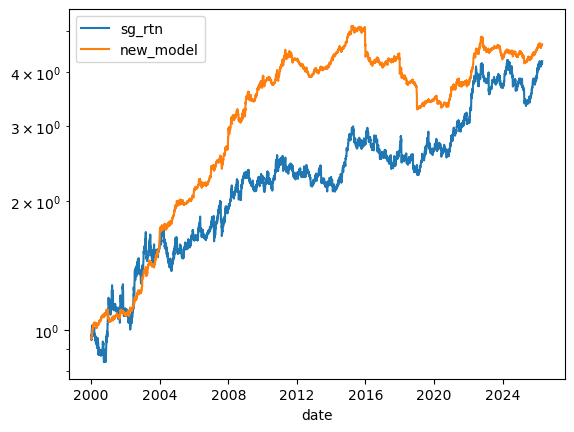

In [126]:
df1.apply(lambda x: np.cumprod(1 + x)).plot(logy = True)

In [128]:
from pykalman import KalmanFilter

In [167]:
def kalman_trend(price):

    y = np.log(price).values

    kf = KalmanFilter(
        transition_matrices=np.array([
            [1, 1],
            [0, 1]
        ]),

        observation_matrices=np.array([
            [1, 0]
        ]),

        transition_covariance=np.array([
            [1e-5, 0],
            [0, 1e-6]
        ]),

        observation_covariance=1e-3,

        initial_state_mean=np.array([
            y[0],
            0
        ]),

        initial_state_covariance=np.eye(2)
    )

    state_means, state_covs = kf.filter(y)

    df = pd.DataFrame(
        index=price.index,
        data={
            "log_price": y,
            "trend": state_means[:, 0],
            "slope": state_means[:, 1]
        }
    )

    return df

In [171]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\FuturesData\PrepFuturesPX.parquet"
df_px = (pd.read_parquet(
    path = path, engine = "pyarrow").
    set_index("date"))

In [178]:
def _get_kf(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = kalman_trend(df.px_val)
    return df_out

df_kf = (df_px.groupby(
    "ticker").
    apply(_get_kf).
    reset_index())

C:\Users\Diego\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Diego\anaconda3\Lib\site-packages\pykalman\standard.py:223: RuntimeWarning: invalid value encountered in dot
  np.dot(transition_matrix, current_state_mean) + transition_offset


In [222]:
df_kf_signal = (df_kf.pivot(
    index = "date", columns = "ticker", values = "trend").
    apply(lambda x: x.diff()).
    apply(lambda x: x / x.ewm(span = 10, adjust = False).std()).
    apply(lambda x: x.ewm(span = 100, adjust = False).mean()).
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "lag_signal").
    dropna())

In [223]:
df_rtn = (df_px.reset_index().pivot(
    index = "date", columns = "ticker", values = "px_val").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "px_rtn").
    dropna())

In [224]:
df_kf_signal = (df_rtn.merge(
    right = df_kf_signal, how = "inner", on = ["date", "ticker"]).
    assign(signal_rtn = lambda x: np.sign(x.px_rtn) * x.lag_signal).
    pivot(index = "date", columns = "ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.5, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "kf_trend"))

In [225]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\GenericSignal\GenericSignal.parquet"
df_gen = (pd.read_parquet(
    path = path, engine = "pyarrow").
    pivot(index = "date", columns = "ticker", values = "signal").
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "lag_signal").
    dropna().
    merge(right = df_rtn, how = "inner", on = ["date", "ticker"]).
    assign(signal_rtn = lambda x: np.sign(x.px_rtn) * x.lag_signal).
    pivot(index = "date", columns = "ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.5, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "gen_trend"))

In [228]:
(df_gen.merge(
    right = df_kf_signal, how = "inner", on = ["date"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)))

gen_trend    1.556642
kf_trend     0.986721
dtype: float64

In [234]:
(df_gen.merge(
    right = df_kf_signal, how = "inner", on = ["date"]).
    assign(tmp = lambda x: x.mean(axis = 1)).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)))

gen_trend    1.556642
kf_trend     0.986721
tmp          1.378262
dtype: float64

In [236]:
path = r"C:\Users\Diego\Documents\GitHub\TrendConvexity\data\FuturesData.parquet"

In [264]:
df_wider = (pd.read_parquet(
    path = path, engine = "pyarrow").
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    pivot(index = "date", columns = "security", values = "PX_LAST"))

In [265]:
df_signal = (df_wider.
    diff().
    apply(lambda x: x / x.ewm(span = 10, adjust = False).std()).
    apply(lambda x: x.ewm(span = 100, adjust = False).mean()).
    shift())

In [266]:
df_signal_rtn = (df_wider.pct_change() * np.sign(df_signal))

In [267]:
df_old_trend = (df_signal_rtn.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    mean(axis = 1).
    to_frame(name = "old_trend"))

In [275]:
df_combineda = (df_gen.merge(
    right = df_old_trend, how = "inner", on = ["date"]).
    dropna())

In [276]:
(df_combineda.corr())

,gen_trend,old_trend
gen_trend,1.00000,0.41039
old_trend,0.41039,1.00000


<Axes: xlabel='date'>

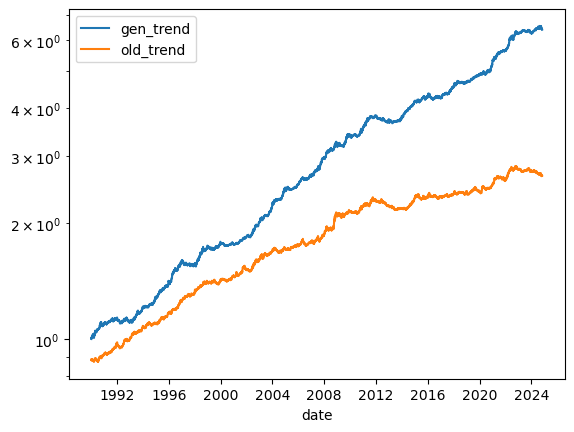

In [277]:
df_combineda.apply(lambda x: np.cumprod(1 + x)).plot(logy = True)

In [341]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\GenericSignal\GenericSignal.parquet"
df_single_tf = (pd.read_parquet(
    path = path, engine = "pyarrow").
    pivot(index = "date", columns = "ticker", values = "signal").
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "lag_signal").
    dropna().
    merge(right = df_rtn, how = "inner", on = ["date", "ticker"]).
    assign(signal_rtn = lambda x: np.sign(x.px_rtn) * x.lag_signal).
    pivot(index = "date", columns = "ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.5, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "trend_rtn").
    dropna())

In [342]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\Benchmarks\TrendIndices.parquet"
df_sg = (pd.read_parquet(
    path = path, engine = "pyarrow").
    query("security == 'NEIXCTAT Index'").
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    set_index("date")
    [["PX_LAST"]].
    sort_index().
    pct_change().
    rename(columns = {"PX_LAST": "sg_rtn"}))

In [370]:
tickers = (df_single_tf.merge(
    right = df_sg, how = "inner", on = ["date"]).
    drop(columns = ["date"]).
    groupby(["ticker"]).
    agg("corr").
    reset_index().
    drop(columns = ["level_1", "trend_rtn"]).
    query("sg_rtn != 1").
    sort_values("sg_rtn", ascending = False).
    ticker.
    tail(20).
    drop_duplicates().
    sort_values().
    to_list())

In [371]:
df_b = (df_single_tf.query(
    "ticker == @tickers").
    drop(columns = ["ticker"]).
    groupby("date").
    agg("mean").
    merge(right = df_sg, how = "inner", on = ["date"]))

In [372]:
df_b.corr()

,trend_rtn,sg_rtn
trend_rtn,1.000000,0.214452
sg_rtn,0.214452,1.000000


<Axes: xlabel='date'>

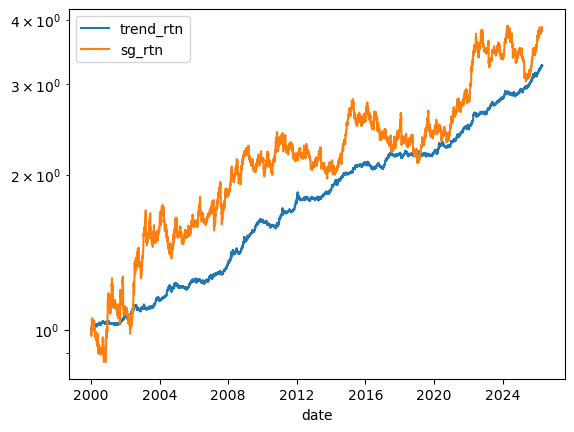

In [373]:
df_b.apply(lambda x: np.cumprod(1 + x)).plot(logy = True)

In [382]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\Benchmarks\TrendIndices.parquet"
df_trend = (pd.read_parquet(
    path = path, engine = "pyarrow").
    query("security == 'NEIXCTAT Index'").
    set_index("date")
    [["PX_LAST"]].
    dropna())

In [383]:
df_trend

,PX_LAST
date,
2000-01-03,997.200
2000-01-04,970.674
2000-01-05,962.133
2000-01-06,953.473
2000-01-07,944.034
...,...
2026-04-17,4180.352
2026-04-20,4185.255
2026-04-21,4199.194
